## ECE1513 Tutorial 4:
### Linear Regression with sklearn and numpy

Linear Regression:

1. Linear regression is used when the dependent variable is continuous and has an unbounded range.
2. The output of linear regression is a continuous value, which could range from negative infinity to positive infinity.
3. It models the relationship between the independent variables and the dependent variable by fitting a linear equation to observed data.
4. Linear regression is commonly used for tasks such as predicting house prices, stock prices, or any other continuous variable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_classification

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

### Section 1: Generating Synthetic Data


In [2]:
# Generate synthetic regression data with 3 features and some noise for realism
X, y = make_regression(n_samples=100, n_features=3, noise=10, random_state=42)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(80, 3) (20, 3) (80,) (20,)


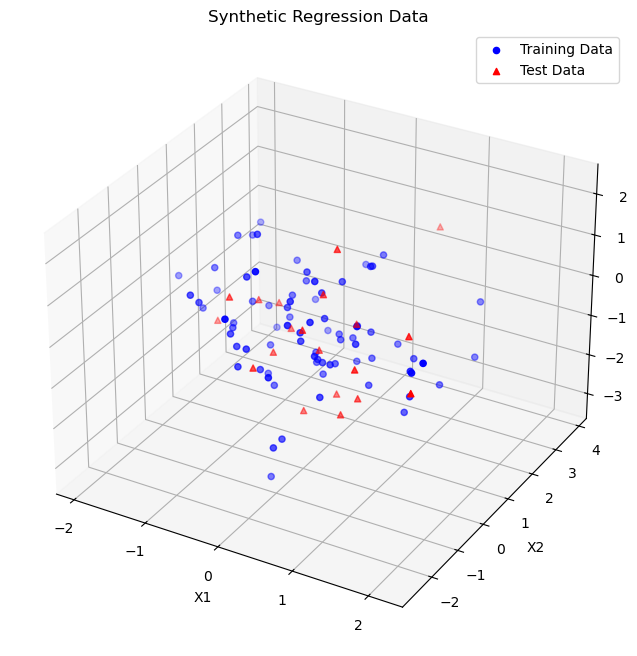

In [3]:
# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c='blue', marker='o', label='Training Data')

ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c='red', marker='^', label='Test Data')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('Synthetic Regression Data')
ax.legend()

plt.show()

### Section 2: Linear Regression with NumPy

$$w^\star=(X^T X)^{-1} X^T y$$

In [4]:
def train_linear_regression(X, y):
    """
    Trains a linear regression model using the normal equation.
    
    Parameters:
        X (np.ndarray): Input features (design matrix).
        y (np.ndarray): Target values.
    
    Returns:
        np.ndarray: Coefficients of the linear regression model.
    """
    # Adding a column of ones for the intercept term: y = b + w1*x1 + w2*x2 + ... + wn*xn
    X_bias = np.hstack([np.ones((X.shape[0], 1)), X])  # Add intercept term to the input features
    
    # Calculate the coefficients using the normal equation (X^T X)^(-1)X^T y
    return np.linalg.pinv(X_bias.T @ X_bias) @ X_bias.T @ y

# Train a linear regression model using synthetic data
coefficients = train_linear_regression(X_train, y_train)
print("Learned Coefficients:", coefficients)

# Predict on the test set
X_test_bias = np.hstack([np.ones((X_test.shape[0], 1)), X_test])  # Add intercept term
y_pred = X_test_bias @ coefficients  # Make predictions

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)  # Compute mean squared error
print("Mean Squared Error on Test Set:", mse)
print("Target Values:", y_test)
print("Predictions:", y_pred)

Learned Coefficients: [ 1.30375945 28.49475136 74.39534965 18.78132401]
Mean Squared Error on Test Set: 123.84680824798106
Target Values: [  21.85731688    2.79729129  -55.51805276  -24.81108317   44.7425582
  299.2706523    46.21469313  -73.29289474 -122.29489791   12.78127599
   42.29544193   33.69367066  -39.33912134  -70.06843444   16.22512072
  -30.4165569   -52.28763285  -38.97147382  -18.41369652   66.69351173]
Predictions: [   2.09318899    0.89599885  -60.6507773   -21.45525368   50.78554934
  312.2425462    25.6908719   -76.36043905 -117.6418961    14.13488097
   61.04573435   23.12331558  -46.63879976  -49.75328272   25.78976519
  -35.52854174  -35.64242991  -44.53990254  -17.2499538    61.22993414]


### Section 3: Linear Regression with SciKit-Learn

In [5]:
# Train a linear regression model using scikit-learn
lr = LinearRegression()
lr.fit(X_train, y_train)  # Fit the model
y_pred_sklearn = lr.predict(X_test)  # Predict on test set

# Evaluate the scikit-learn model
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)  # Compute mean squared error
print("Mean Squared Error (SciKit-Learn) on Test Set:", mse_sklearn)

Mean Squared Error (SciKit-Learn) on Test Set: 123.84680824798056


### Section 4: Comparison and Visualization


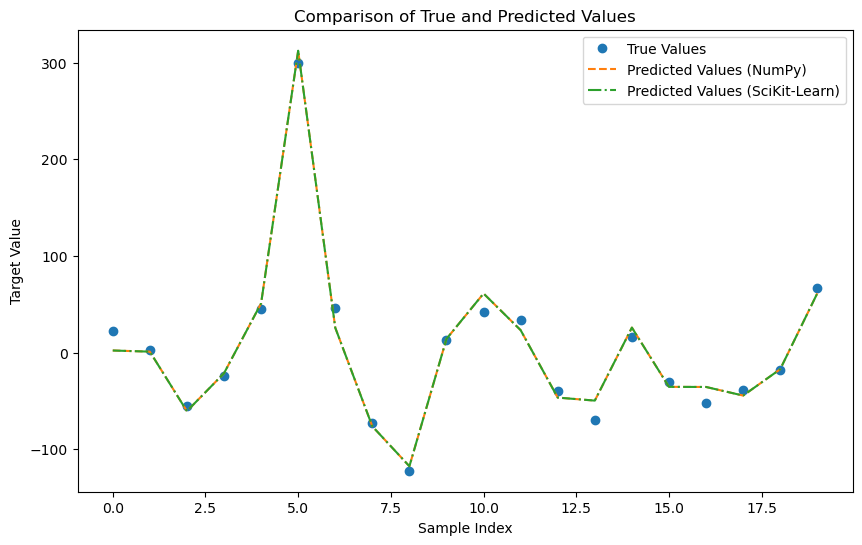

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='True Values', marker='o', linestyle='None')
plt.plot(y_pred, label='Predicted Values (NumPy)', linestyle='--')
plt.plot(y_pred_sklearn, label='Predicted Values (SciKit-Learn)', linestyle='-.')
plt.legend()
plt.title('Comparison of True and Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.show()

### [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
Logistic Regression:

1. Logistic regression is used when the dependent variable is categorical. Typically, it's used for binary classification problems, although it can be extended to handle multi-class classification.
2. The output of logistic regression is a probability that the given input point belongs to a particular class. This probability is then converted into a binary outcome using a threshold (usually 0.5).
3. It models the relationship between the independent variables and the probability of a particular outcome occurring using the logistic function (sigmoid function), which constrains the output between 0 and 1.
4. Logistic regression is commonly used in various fields for tasks such as spam detection, credit risk analysis, medical diagnosis, etc.


In [7]:
X, y = make_classification(n_samples= 1000, n_features=2, n_redundant = 0, random_state=7)
print(X.shape)
print(y.shape)

(1000, 2)
(1000,)


Training data shape:  (700, 2)
Training labels shape:  (700,)
Testing data shape:  (300, 2)
Testing labels shape:  (300,)


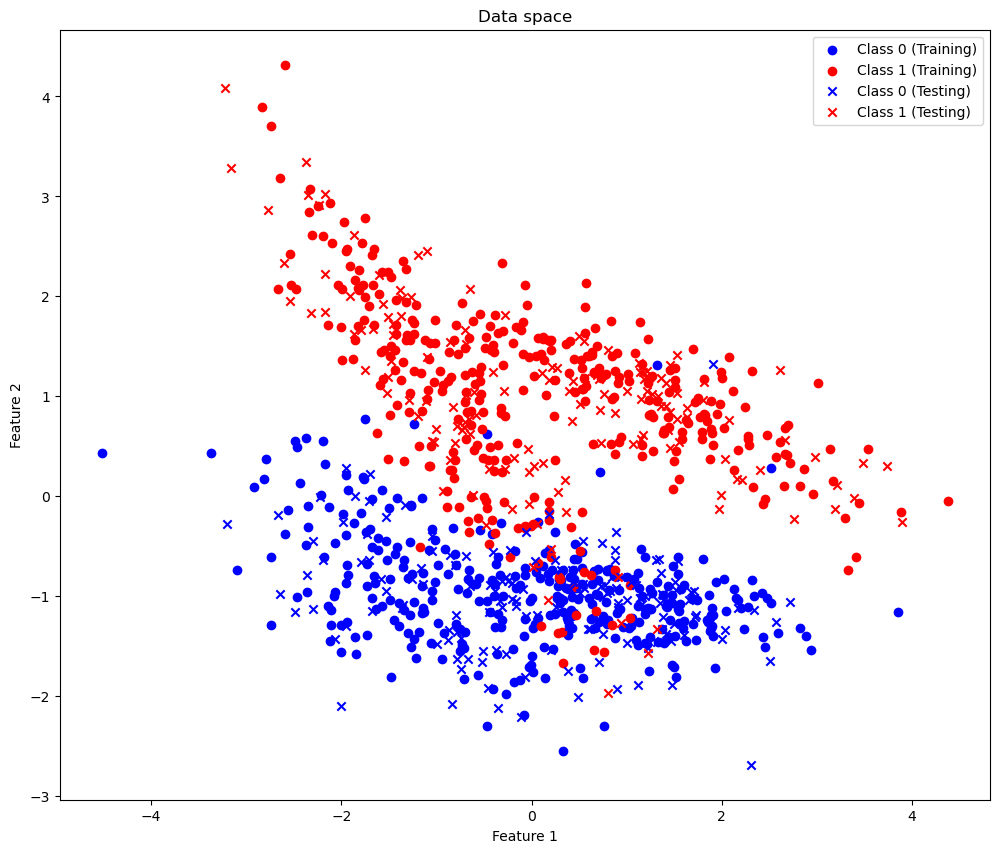

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

print("Training data shape: ", X_train.shape)
print("Training labels shape: ", y_train.shape)
print("Testing data shape: ", X_test.shape)
print("Testing labels shape: ", y_test.shape)
plt.figure(figsize=(12, 10))

# Plot training points
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='blue', label='Class 0 (Training)', marker='o')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='red', label='Class 1 (Training)', marker='o')
# Plot testing points
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='blue', label='Class 0 (Testing)', marker='x')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='red', label='Class 1 (Testing)', marker='x')

plt.title("Data space")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='best')
plt.show()

In [9]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Calculate training and testing loss
train_loss = log_loss(y_train, log_reg.predict_proba(X_train))
test_loss = log_loss(y_test, log_reg.predict_proba(X_test))

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train, log_reg.predict(X_train))
test_accuracy = accuracy_score(y_test, log_reg.predict(X_test))

print(f"Logistic Regression - Training Loss: {train_loss:.2f}, Testing Loss: {test_loss:.2f}")
print(f"Logistic Regression - Training Accuracy: {train_accuracy:.2f}, Testing Accuracy: {test_accuracy:.2f}")


Logistic Regression - Training Loss: 0.22, Testing Loss: 0.20
Logistic Regression - Training Accuracy: 0.93, Testing Accuracy: 0.95


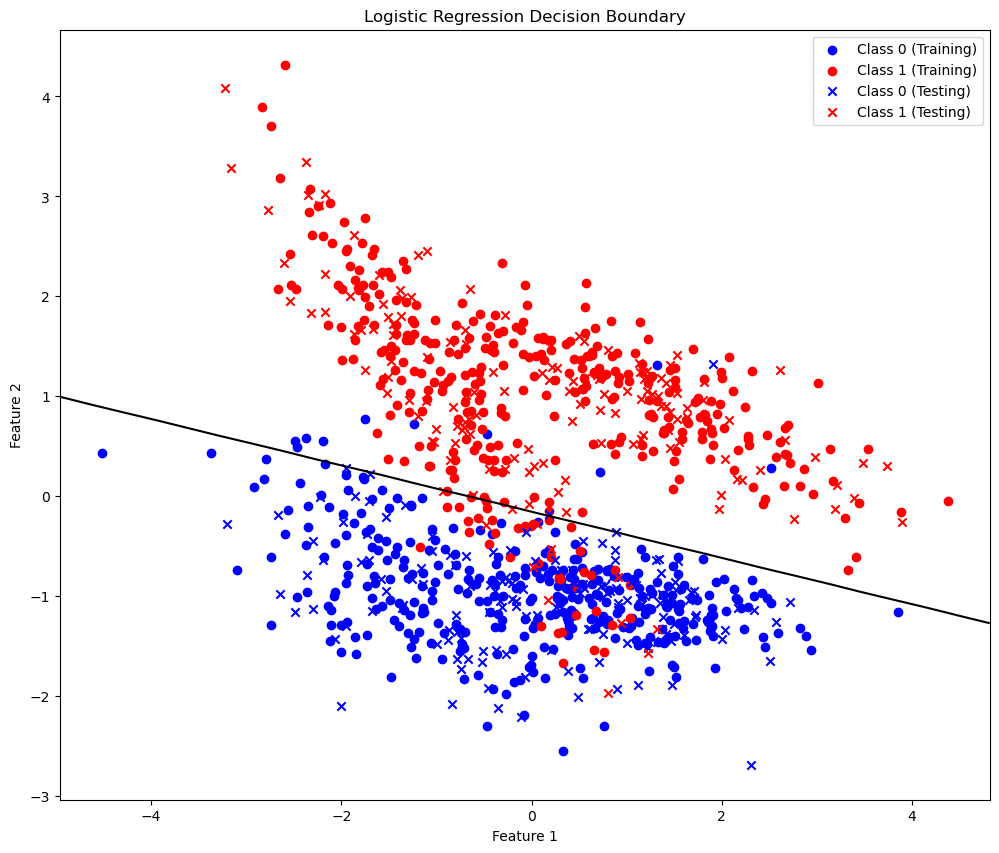

In [10]:
plt.figure(figsize=(12, 10))

# Plot training points
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='blue', label='Class 0 (Training)', marker='o')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='red', label='Class 1 (Training)', marker='o')

# Plot testing points
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='blue', label='Class 0 (Testing)', marker='x')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='red', label='Class 1 (Testing)', marker='x')

# Plot decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = log_reg.predict_proba(xy)[:, 1].reshape(XX.shape)

# Contour plot for decision boundary
ax.contour(XX, YY, Z, levels=[0.5], colors='k', linestyles='-')

plt.title("Logistic Regression Decision Boundary")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='best')
plt.show()